In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
import random

%matplotlib inline

In [2]:
words = open("names.txt", "r").read().splitlines()
len(words)

32033

In [3]:
# get distinct chars across all words -- build vocab
chars = sorted(list(set("".join(words))))

# map chars to and from integers
# 0th char will be "." which denotes start/end of a word
char_to_int = {ch: idx + 1 for idx, ch in enumerate(chars)}
char_to_int["."] = 0
int_to_char = {idx: ch for ch, idx in char_to_int.items()}

print(char_to_int)
print(int_to_char)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [13]:
# build train, eval and test datasets
# X: 3 chars --> Y: next char
# For word "emma"
# ... --> e
# ..e --> m
# .em --> m
# emm --> a
# mma --> .

context_length = 3


def get_dataset(words):
    X, y = [], []
    for word in words:
        # start at [., ., .] case whose int rep would be [0, 0, 0]
        context = [0] * context_length
        for ch in word + ".":
            ch_idx = char_to_int[ch]
            X.append(context)
            y.append(ch_idx)
            # update context
            context = context[1:] + [ch_idx]
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y


# split the dataset into train, val and test into 80-10-10 split
random.seed(42)
random.shuffle(words)

limit1 = int(0.8 * len(words))
limit2 = int(0.9 * len(words))

X_train, y_train = get_dataset(words=words[:limit1])
X_val, y_val = get_dataset(words=words[limit1:limit2])
X_test, y_test = get_dataset(words=words[limit2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [14]:
# Initialize parameters of the network
# C --> embedding matrix. Embeds each character into an d-dimensional vector. Here, d=2
# (W1, b1) and (W2, b2) --> Two MLP layers

# Architecture
# input --> input_thro_2d_embedding --> flatten --> layer 1 (100 neurons)   --> layer 2 (27 neurons)
# (n, 3)--> (n, 3, 2)               --> (n, 6)  --> layer outputs: (n, 100) --> layer outputs (n, 27)

# Layer 2 is intentionally set to have 27 neurons to give us (n, 27) as output
# It tells what score our model gives to each of the 27 characters for a given example.
# We would want our model to give maximum score to the character next in input example's sequence.

emb_dims = 2
unique_chars = len(chars) + 1

g = torch.Generator().manual_seed(6)
C = torch.randn((unique_chars, emb_dims), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100, unique_chars), generator=g, requires_grad=True)
b2 = torch.randn(unique_chars, generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

NOTE: Pytorch broadcasting semantics: https://docs.pytorch.org/docs/2.12/notes/broadcasting.html

Two tensors are “broadcastable” if the following rules hold:

When iterating over the dimension sizes, starting at the trailing dimension, the dimension sizes must either be equal, one of them is 1, or one of them does not exist.



In [ ]:
# Training using full dataset (no batching)


def train_using_full_dataset():
    lr = 0.1  # learning rate
    loss_tracker = []
    step_tracker = []

    for i in range(1000):
        # --------------------FORWARD PASS---------------------------
        # input thro embedding matrix
        X_emb = C[X_train]  # (n, 3) --> (n, 3, 2)
        # embedded matrix is flattened
        X_emb = X_emb.view(-1, context_length * emb_dims)  # (n, 6)
        # layer 1
        X_layer1_out = torch.tanh(X_emb @ W1 + b1)  # (n, 100)
        # layer 2
        logits = X_layer1_out @ W2 + b2  # (n, 27)
        # cross-entropy loss
        loss = F.cross_entropy(logits, y_train)

        # --------------------BACK PROP-------------------------------
        # set grad to None for all parameters
        for p in parameters:
            p.grad = None
        # run backprop
        loss.backward()

        # run gradient descent
        for p in parameters:
            p.data += -lr * p.grad

        # we track log10 of cross-entropy loss for easier viz
        step_tracker.append(i)
        loss_tracker.append(loss.log10().item())
    return step_tracker, loss_tracker


# Uncomment the following to run
# si, li = train_using_full_dataset()
# plt.plot(si, li)

In [15]:
# Training using batches

batch_size = 32
lr = 0.1  # learning rate
loss_tracker = []
step_tracker = []

for i in range(20000):
    # --------------------MINIBATCH------------------------------
    batch_idx = torch.randint(0, X_train.shape[0], (batch_size,))
    X_batch = X_train[batch_idx]
    y_batch = y_train[batch_idx]

    # --------------------FORWARD PASS---------------------------
    # input thro embedding matrix
    X_emb = C[X_batch]  # (n, 3) --> (n, 3, 2)
    # embedded matrix is flattened
    X_emb = X_emb.view(-1, context_length * emb_dims)  # (n, 6)
    # layer 1
    X_layer1_out = torch.tanh(X_emb @ W1 + b1)  # (n, 100)
    # layer 2
    logits = X_layer1_out @ W2 + b2  # (n, 27)
    # cross-entropy loss
    loss = F.cross_entropy(logits, y_batch)

    # --------------------BACK PROP-------------------------------
    # set grad to None for all parameters
    for p in parameters:
        p.grad = None
    # run backprop
    loss.backward()

    # add LR decay
    lr = 0.1 if i < 10000 else 0.01

    # run gradient descent
    for p in parameters:
        p.data += -lr * p.grad

    # we track log10 of cross-entropy loss for easier viz
    step_tracker.append(i)
    loss_tracker.append(loss.log10().item())

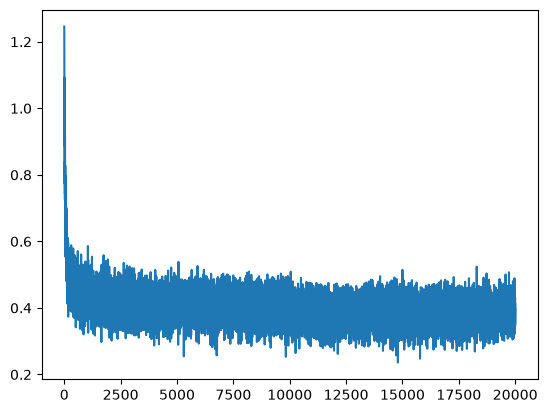

In [16]:
plt.plot(step_tracker, loss_tracker)

In [19]:
# loss computation on complete train/val/test sets by running single forward pass on our trained model

# now that we have a model ready (parameters have been trained), we calculate loss on entire training set


def single_forward_pass(X, y):
    X_emb = C[X]  # (n, 3) --> (n, 3, 2)
    X_emb = X_emb.view(-1, context_length * emb_dims)  # (n, 6)
    X_layer1_out = torch.tanh(X_emb @ W1 + b1)  # (n, 100)
    logits = X_layer1_out @ W2 + b2  # (n, 27)
    loss = F.cross_entropy(logits, y)
    print(loss.item())


print("Training loss")
single_forward_pass(X=X_train, y=y_train)

print("\n Validation loss")
single_forward_pass(X=X_val, y=y_val)

print("\n Test loss")
single_forward_pass(X=X_test, y=y_test)

Training loss
2.429224967956543

 Validation loss
2.4428837299346924

 Test loss
2.4387974739074707


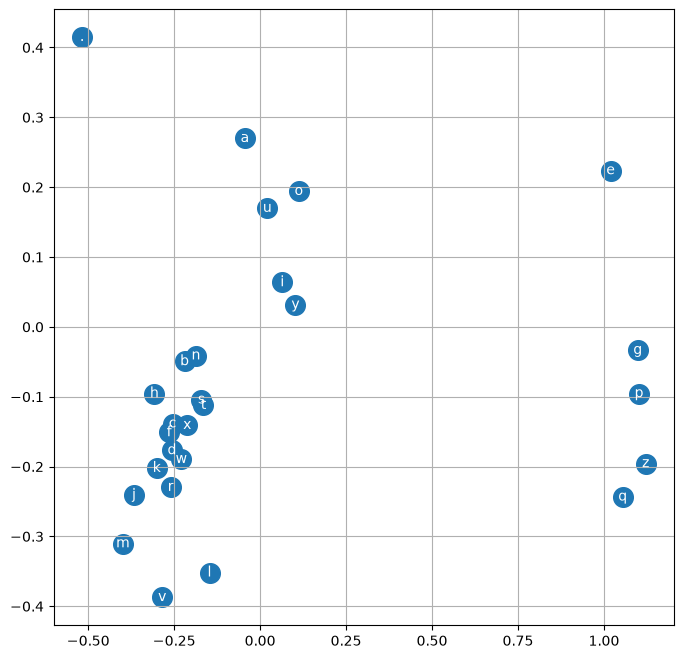

In [ ]:
# Viz embedding space
# Reference: https://colab.research.google.com/drive/1YIfmkftLrz6MPTOO9Vwqrop2Q5llHIGK?usp=sharing#scrollTo=DwOgCg1vdNhe

# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(
        C[i, 0].item(),
        C[i, 1].item(),
        int_to_char[i],
        ha="center",
        va="center",
        color="white",
    )
plt.grid("minor")  # validation loss